# CONFLUENCE Tutorial - 4: Semi-Distributed Basin Workflow (Tuolumne River at Yosemite)

## Semi-Distributed Modeling Philosophy
Semi-distributed modeling divides the watershed into multiple sub-basins, with each unit treated as a separate modeling component within a connected network. This approach employs spatial discretization where the watershed is divided into multiple GRUs based on stream network topology, creating connected units where each GRU links to downstream units through a routing network. The methodology represents intermediate complexity that provides more spatial realism than lumped models while maintaining greater simplicity than fully distributed approaches, ensuring computational efficiency with fewer units than fully distributed models while remaining suitable for calibration and uncertainty analysis.

## Key Scientific Concepts
The Grouped Response Unit concept represents sub-basins that drain to specific points along the stream network, with each GRU containing similar hydrological characteristics and responding as a unified computational unit. Stream network delineation employs digital elevation models and flow accumulation algorithms to automatically identify stream channels and divide the watershed into connected sub-basins. Routing processes move water from upstream GRUs to downstream GRUs through the stream network while accounting for travel time and channel storage effects. The stream threshold parameter critically controls model complexity by determining how many sub-basins are created, with higher thresholds producing fewer, larger GRUs.

## Scientific Advantages and Applications
Semi-distributed modeling captures important spatial variations in climate, topography, and land cover across the watershed while better representing elevation-dependent processes like snow accumulation and temperature gradients. This approach maintains computational efficiency with fewer units than fully distributed models while preserving key spatial patterns, explicitly represents routing dynamics including travel time and attenuation effects in the stream network, and provides diagnostic capabilities that allow examination of contributions from different watershed regions.

## Technical Implementation Framework
The semi-distributed approach integrates several key components through automated watershed delineation that identifies sub-basins using flow accumulation algorithms, stream network extraction that creates river network topology connecting the sub-basins, GRU characterization that calculates average characteristics for each sub-basin, routing setup that configures mizuRoute to move water between GRUs, and model integration that couples SUMMA land surface processes with mizuRoute routing capabilities.

## Step 1: Semi-Distributed Setup with Data Reuse
Building on the lumped basin modeling from Tutorial 02a, we now advance to semi-distributed watershed modeling. This represents an optimal balance between computational efficiency and spatial realism: multiple connected sub-basins that capture key spatial heterogeneity while maintaining manageable model complexity.

The same CONFLUENCE framework seamlessly handles this complexity increase while data reuse from Tutorial 02a eliminates redundant preprocessing, demonstrating efficient workflow management for iterative model development.

In [1]:
import os
os.getcwd()
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')

In [2]:
# Import the libraries we'll need in this notebook
import sys
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import datetime
import xarray as xr
import numpy as np
import shutil

# Add CONFLUENCE to path
confluence_path = Path().resolve()
sys.path.append(str(confluence_path))

# Import main CONFLUENCE class
from CONFLUENCE import CONFLUENCE

# import custom utility functions
from utils.custom.calc import *
from utils.custom.plotting import *
from utils.custom.adjust_settings import *

# Set up plotting style
plt.style.use('default')
%matplotlib inline

In [3]:
today = datetime.today().strftime('%Y%m%d')
relevant_detail = 'parkingLot'  # Update this based on the specific model configuration (e.g., 'lumped', 'semi_distributed')
name = f'{today}_{relevant_detail}'
# =============================================================================
# CONFIGURATION FOR SEMI-DISTRIBUTED TUOLUMNE RIVER MODELING
# =============================================================================

# Set directory paths
CONFLUENCE_CODE_DIR = confluence_path
CONFLUENCE_DATA_DIR = Path('/scratch/dlhogan/ess-project-data/') 

# Load template configuration and customize for semi-distributed modeling
config_template_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_Tuolumne.yaml'

with open(config_template_path, 'r') as f:
    config_dict = yaml.safe_load(f)

# Update for semi-distributed Tuolumne River modeling
config_updates = {
    'CONFLUENCE_CODE_DIR': str(CONFLUENCE_CODE_DIR),
    'CONFLUENCE_DATA_DIR': str(CONFLUENCE_DATA_DIR),
    'DOMAIN_NAME': 'Tuolumne_River',
    'EXPERIMENT_ID': f'{name}',  # Update experiment ID
    'DOMAIN_DEFINITION_METHOD': 'delineate',    # KEY CHANGE: watershed delineation vs lumped
    'STREAM_THRESHOLD': 5000,                   # Controls number of sub-basins
    'DOMAIN_DISCRETIZATION': 'GRUs',            # Grouped Response Units
    'SPATIAL_MODE': 'Semi_Distributed',               # Changed from 'Lumped'
    'HYDROLOGICAL_MODEL': 'SUMMA',
    'ROUTING_MODEL': 'mizuRoute',
    'EXPERIMENT_TIME_START': '2011-10-01 00:00',
    'EXPERIMENT_TIME_END':  '2022-09-30 23:00',
    'CALIBRATION_PERIOD': '2013-10-01, 2015-09-30',
    'EVALUATION_PERIOD': '2015-10-01, 2018-09-30',
    'SPINUP_PERIOD': '2011-10-01, 2013-09-30',
    'MPI_PROCESSES': 1,                       # Adjust based on available resources
    'TAUDEM_DIR': '/home/dlhogan/tools/src/TauDEM/bin',
    'DELINEATION_METHOD': 'TauDEM',  # Changed from 'TauDEM'
    'CATCHMENT_SHP_HRUID': 'HRU_ID',          # Updated HRU ID field
    'CATCHMENT_SHP_GRUID': 'GRU_ID',
    'SIM_REACH_ID': -1,                       # Changed to East River outlet reach ID
    'ROUTING_DELINEATION': 'lumped',        # Changed to 'lumped' or remove
    'APPLY_LAPSE_RATE': True,                 # Changed to True to apply lapse rate
    'OPTIMIZATION_METRIC': 'NSE',          # Changed to 'NSE' for emulation
    'ITERATIVE_OPTIMIZATION_ALGORITHM': 'DDS',  # Changed to 'DDS' for optimization
    'NUMBER_OF_ITERATIONS': 12,
    'BASIN_PARAMS_TO_CALIBRATE': 'basin__aquiferScaleFactor, basin__aquiferHydCond',
    'PARAMS_TO_CALIBRATE': 'k_soil, theta_sat, theta_res, aquiferScaleFactor, rootingDepth',
    'SUMMA_RUNOFF_VAR': 'scalarTotalRunoff'    # Use scalarTotalRunoff for calibration (not averageRoutedRunoff)
}

config_dict.update(config_updates)

# Save configuration
temp_config_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_Tuolumne_distributed.yaml'
with open(temp_config_path, 'w') as f:
    yaml.dump(config_dict, f, default_flow_style=False, sort_keys=False)

# Initialize CONFLUENCE
confluence = CONFLUENCE(temp_config_path)

# Display configuration
print("=== Directory Configuration ===")
print(f"Code Directory: {CONFLUENCE_CODE_DIR}")
print(f"Data Directory: {CONFLUENCE_DATA_DIR}")
print("\n=== Key Configuration Settings ===")
print(f"Domain Name: {confluence.config['DOMAIN_NAME']}")
print(f"Pour Point: {confluence.config['POUR_POINT_COORDS']}")
print(f"Spatial Mode: {confluence.config['SPATIAL_MODE']}")
print(f"Model: {confluence.config['HYDROLOGICAL_MODEL']}")
print(f"Simulation Period: {confluence.config['EXPERIMENT_TIME_START']} to {confluence.config['EXPERIMENT_TIME_END']}")
print(f"Basin Parameters to Calibrate: {confluence.config['BASIN_PARAMS_TO_CALIBRATE']}")

2026-02-26 16:43:00 ● CONFLUENCE Logging Initialized
2026-02-26 16:43:00 ● Domain: Tuolumne_River
2026-02-26 16:43:00 ● Experiment ID: 20260226_parkingLot
2026-02-26 16:43:00 ● Log Level: INFO
2026-02-26 16:43:00 ● Log File: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/_workLog_Tuolumne_River/confluence_general_Tuolumne_River_20260226_164300.log
2026-02-26 16:43:00 ● Configuration logged to: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/_workLog_Tuolumne_River/config_Tuolumne_River_20260226_164300.yaml
2026-02-26 16:43:00 ● Initializing VariableHandler for dataset: ERA5 and model: SUMMA
2026-02-26 16:43:00 ● CONFLUENCE initialized with config: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_Tuolumne_distributed.yaml
=== Directory Configuration ===
Code Directory: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro
Data Directory: /scratch/dlhogan/ess-project-data

=== Key Configuration Settings ===
Domain Name: Tuol

### Model Decision & Parameter Changes

In [4]:
# =============================================================================
# PARAMETER AND MANUAL MODEL SETUP FOR STANDARD RUNS
# ============================================================================= 
# NOTE: For DDS parameter calibration optimization, use: python optimize_confluence.py
# The standalone script handles all parameter management and preprocessing automatically.

from utils.custom.adjust_settings import edit_modelDecisions, update_and_reformat_parameter_file

# Define base settings paths (READ ONLY - do not modify!)
base_settings_dir = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_base_settings/SUMMA")

# Define working copy directory in scratch
project_settings_dir = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / "settings" / "SUMMA"
project_settings_dir.mkdir(parents=True, exist_ok=True)

print("📋 Setting up parameters for manual run...")

# Copy base settings
for fname in ["modelDecisions.txt", "localParamInfo.txt", "basinParamInfo.txt"]:
    shutil.copy(base_settings_dir / fname, project_settings_dir / fname)

modelDecision_file = project_settings_dir / "modelDecisions.txt"
localParamInfo_file = project_settings_dir / "localParamInfo.txt"
basinParamInfo_file = project_settings_dir / "basinParamInfo.txt"

# Update model decisions
edit_modelDecisions(modelDecision_file, {
    'groundwatr': 'bigBuckt',
    'bcLowrSoiH': 'drainage',
    'spatial_gw': 'localColumn',
    'alb_method': 'varDecay'
})

# Manual parameter values for this run
print("\n✏️  Using manually specified parameter values...")
localParamInfo_updates = {
    'tempCritRain': 274.1000,
    'k_soil': 9.4e-6,
    'theta_sat': 0.5160,
    'theta_res': 0.0270,
    'rootingDepth': 6.876,
}

basinParamInfo_updates = {
    "basin__aquiferHydCond": 0.0010,
    "basin__aquiferScaleFactor": 50.0000,
    "routingGammaShape": 2.5000,
    "routingGammaScale": 4.6e4,
}

# Update parameter files
for updates, file in [(localParamInfo_updates, localParamInfo_file), 
                      (basinParamInfo_updates, basinParamInfo_file)]:
    update_and_reformat_parameter_file(file, updates, reformat_all=True)

print(f"✓ Parameters ready at: {project_settings_dir}")

📋 Setting up parameters for manual run...

✏️  Using manually specified parameter values...
Updated localParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision
Updated basinParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision
✓ Parameters ready at: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/settings/SUMMA


In [5]:
# Project Initialization
project_dir = confluence.managers['project'].setup_project()

# Create pour point
pour_point_path = confluence.managers['project'].create_pour_point()

# List created directories
print("\nCreated directories:")
for item in sorted(project_dir.iterdir()):
    if item.is_dir():
        print(f"  📁 {item.name}")

print("\nDirectory purposes:")
print("  📁 shapefiles: Domain geometry (watershed, pour points, river network)")
print("  📁 attributes: Static characteristics (elevation, soil, land cover)")
print("  📁 forcing: Meteorological inputs (precipitation, temperature)")
print("  📁 simulations: Model outputs")
print("  📁 evaluation: Performance metrics and comparisons")
print("  📁 plots: Visualizations")
print("  📁 optimisation: Calibration results")

2026-02-26 16:43:02 ● Setting up project for domain: Tuolumne_River
2026-02-26 16:43:02 ● Project directory created at: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River
2026-02-26 16:43:02 ● Pour point shapefile created successfully: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/shapefiles/pour_point/Tuolumne_River_pourPoint.shp

Created directories:
  📁 _workLog_Tuolumne_River
  📁 attributes
  📁 forcing
  📁 observations
  📁 optimisation
  📁 plots
  📁 settings
  📁 shapefiles

Directory purposes:
  📁 shapefiles: Domain geometry (watershed, pour points, river network)
  📁 attributes: Static characteristics (elevation, soil, land cover)
  📁 forcing: Meteorological inputs (precipitation, temperature)
  📁 simulations: Model outputs
  📁 evaluation: Performance metrics and comparisons
  📁 plots: Visualizations
  📁 optimisation: Calibration results


### Data Re-use from lumped model run

In [6]:
# =============================================================================
# DATA REUSE FROM TUTORIAL 02A
# =============================================================================

# Check for existing data from lumped model tutorial
lumped_domain = 'Tuolumne_River'  # From Tutorial 02a
lumped_data_dir = CONFLUENCE_DATA_DIR / f'domain_{lumped_domain}_lumped'

if lumped_data_dir.exists():
    print(f"✅ Found existing data from Tutorial 02a: {lumped_data_dir}")
    
    # Define reusable data categories
    reusable_data = {
        'Elevation (DEM)': lumped_data_dir / 'attributes' / 'elevation',
        'Soil Data': lumped_data_dir / 'attributes' / 'soilclass', 
        'Land Cover': lumped_data_dir / 'attributes' / 'landclass',
        'ERA5 Forcing': lumped_data_dir / 'forcing' / 'merged_data',
        'WSC Observations': lumped_data_dir / 'observations' / 'streamflow'
    }
    
    # Check availability and copy reusable data
    print(f"\n🔄 Copying and Adapting Reusable Data...")
    
    # Initialize CONFLUENCE first to create directory structure
    confluence = CONFLUENCE(temp_config_path)
    project_dir = confluence.managers['project'].setup_project()
    
    def adapt_name(filename, old_name, new_name):
        """Adapt filenames from lumped to semi-distributed naming."""
        updated = filename.replace(f"{old_name}_lumped", new_name)
        updated = updated.replace(old_name, new_name)
        updated = updated.replace("_lumped_", "_semi_distributed_")
        updated = updated.replace("_lumped.", "_semi_distributed.")
        return updated

    def copy_with_name_adaptation(src_path, dst_path, old_name, new_name):
        """Copy files with name adaptation for new domain"""
        if not src_path.exists():
            return False
            
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        
        if src_path.is_dir():
            # Copy directory contents with name adaptation
            for src_file in src_path.rglob('*'):
                if src_file.is_file():
                    rel_path = src_file.relative_to(src_path)
                    # Adapt filename
                    new_filename = adapt_name(src_file.name, old_name, new_name)
                    dst_file = dst_path / rel_path.parent / new_filename
                    dst_file.parent.mkdir(parents=True, exist_ok=True)
                    shutil.copy2(src_file, dst_file)
            return True
        elif src_path.is_file():
            # Copy single file with name adaptation
            new_filename = adapt_name(dst_path.name, old_name, new_name)
            dst_file = dst_path.parent / new_filename
            dst_file.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_path, dst_file)
            return True
        return False
    
    # Copy reusable data with appropriate naming
    for data_type, src_path in reusable_data.items():
        if src_path.exists():
            # Determine destination path
            rel_path = src_path.relative_to(lumped_data_dir)
            dst_path = project_dir / rel_path
            
            # Copy with name adaptation
            success = copy_with_name_adaptation(
                src_path, dst_path, 
                lumped_domain, config_dict['DOMAIN_NAME']
            )
            
            if success:
                print(f"   ✅ {data_type}: Copied and adapted")
            else:
                print(f"   ⚠️  {data_type}: Copy failed")
        else:
            print(f"   📋 {data_type}: Not found, will acquire fresh")
    
else:
    print(f"⚠️  No existing data found from Tutorial 02a")
    print(f"   Will acquire all data from scratch")
    
    # Initialize CONFLUENCE and create project structure
    confluence = CONFLUENCE(temp_config_path)
    project_dir = confluence.managers['project'].setup_project()

# Create pour point
pour_point_path = confluence.managers['project'].create_pour_point()


✅ Found existing data from Tutorial 02a: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped

🔄 Copying and Adapting Reusable Data...
2026-02-26 16:43:04 ● CONFLUENCE Logging Initialized
2026-02-26 16:43:04 ● Domain: Tuolumne_River
2026-02-26 16:43:04 ● Experiment ID: 20260226_parkingLot
2026-02-26 16:43:04 ● Log Level: INFO
2026-02-26 16:43:04 ● Log File: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/_workLog_Tuolumne_River/confluence_general_Tuolumne_River_20260226_164304.log
2026-02-26 16:43:04 ● Configuration logged to: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/_workLog_Tuolumne_River/config_Tuolumne_River_20260226_164304.yaml
2026-02-26 16:43:04 ● Initializing VariableHandler for dataset: ERA5 and model: SUMMA


2026-02-26 16:43:04 ● CONFLUENCE initialized with config: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_Tuolumne_distributed.yaml
2026-02-26 16:43:04 ● Setting up project for domain: Tuolumne_River
2026-02-26 16:43:04 ● Project directory created at: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River
   ✅ Elevation (DEM): Copied and adapted
   ✅ Soil Data: Copied and adapted
   ✅ Land Cover: Copied and adapted
   ✅ ERA5 Forcing: Copied and adapted
   ✅ WSC Observations: Copied and adapted
2026-02-26 16:43:04 ● Pour point shapefile created successfully: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/shapefiles/pour_point/Tuolumne_River_pourPoint.shp


## Step 2: Stream Network Delineation and Spatial Connectivity
The transition to semi-distributed modeling requires sophisticated spatial analysis to automatically identify sub-basins and their connectivity. This process transforms a continuous landscape into a network of connected modeling units that preserve the essential topology of watershed drainage while creating computationally-manageable spatial discretization.
Scientific Context: Stream Network Analysis
Hydrologic Network Principles:

- Flow Accumulation: Upslope area contributing to each grid cell
- Stream Threshold: Minimum contributing area to define stream channels
- Watershed Segmentation: Division of landscape by stream network topology
- Connectivity Preservation: Maintaining upstream-downstream relationships
- Scale Optimization: Balancing spatial detail with computational tractability

The stream threshold parameter critically controls model complexity: lower values create more sub-basins with finer spatial detail, while higher values produce fewer, larger units with reduced computational demands.

In [7]:
# Check if DEM was copied from Tutorial 02a, otherwise run data acquisition
dem_path = project_dir / 'attributes' / 'elevation' / 'dem'

In [8]:
if not dem_path.exists() or len(list(dem_path.glob('*.tif'))) == 0:
    print(f"   DEM not found, acquiring fresh geospatial attributes...")
    confluence.managers['data'].acquire_attributes()
    print("✅ Geospatial attributes acquired")
else:
    print(f"✅ DEM available from previous workflow")

# Executing stream network delineation
watershed_path = confluence.managers['domain'].define_domain()
print("✅ Stream network delineation complete")

# Execute domain discretization to create GRUs
hru_path = confluence.managers['domain'].discretize_domain()
print("✅ GRU discretization complete")

✅ DEM available from previous workflow
2026-02-26 16:43:06 ● Domain definition workflow starting with: delineate
2026-02-26 16:43:06 ● Starting geofabric delineation for Tuolumne_River
2026-02-26 16:43:06 ● Created interim directory: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/taudem-interim-files/d8
2026-02-26 16:43:06 ● Running command: mpirun -n 1 /home/dlhogan/tools/src/TauDEM/bin/pitremove -z /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/attributes/elevation/dem/domain_Tuolumne_River_elv.tif -fel /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/taudem-interim-files/d8/elv-fel.tif -v
2026-02-26 16:43:07 ● Command output: On input demfile: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/attributes/elevation/dem/domain_Tuolumne_River_elv.tif
On input newfile: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/taudem-interim-files/d8/elv-fel.tif
Not Using mask file: N/A
PitRemove version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domai

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/osgeo/gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


2026-02-26 16:43:12 ● Found 6 rows with duplicate GRU_ID values
2026-02-26 16:43:12 ● Removed 6 duplicate GRU_IDs, keeping the largest area for each
2026-02-26 16:43:12 ● Remaining GRUs: 54
2026-02-26 16:43:12 ● Ensuring CRS consistency. Target CRS: EPSG:4326
2026-02-26 16:43:13 ● Found 2 rows with duplicate GRU_ID values
2026-02-26 16:43:13 ● Removed 2 duplicate GRU_IDs, keeping the largest area for each
2026-02-26 16:43:13 ● Remaining GRUs: 13
2026-02-26 16:43:13 ● Subset basins shapefile saved to: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/shapefiles/river_basins/Tuolumne_River_riverBasins_delineate.shp
2026-02-26 16:43:13 ● Subset rivers shapefile saved to: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/shapefiles/river_network/Tuolumne_River_riverNetwork_delineate.shp
2026-02-26 16:43:13 ● Cleaned up intermediate files: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/taudem-interim-files
2026-02-26 16:43:13 ● Geofabric delineation completed for Tuolum

### Network Structure Analysis and Visualization

In [9]:
import rasterio as rio

In [10]:
from rasterstats import zonal_stats

# Load basins first to add elevation statistics
basin_files = list((project_dir / 'shapefiles' / 'river_basins').glob('*.shp'))
if basin_files:
    basins_temp = gpd.read_file(basin_files[0])
    
    # Find DEM file
    dem_files = list((project_dir / 'attributes' / 'elevation' / 'dem').glob('*_elv.tif'))
    
    if dem_files:
        dem_path = dem_files[0]
        print(f"📊 Calculating elevation statistics from: {dem_path.name}")
        
        # Calculate zonal statistics for each basin
        stats = zonal_stats(
            basins_temp.geometry, 
            str(dem_path),
            stats=['mean', 'min', 'max', 'std'],
            nodata=-9999
        )
        
        # Add elevation statistics to GeoDataFrame
        basins_temp['elevation'] = [s['mean'] if s['mean'] is not None else np.nan for s in stats]
        basins_temp['elev_min'] = [s['min'] if s['min'] is not None else np.nan for s in stats]
        basins_temp['elev_max'] = [s['max'] if s['max'] is not None else np.nan for s in stats]
        basins_temp['elev_std'] = [s['std'] if s['std'] is not None else np.nan for s in stats]
        
        # Save updated shapefile back
        basins_temp.to_file(basin_files[0])
        
        print(f"✅ Added elevation statistics to basins:")
        print(f"   Mean elevation range: {basins_temp['elevation'].min():.0f}m - {basins_temp['elevation'].max():.0f}m")
    else:
        print("⚠️  DEM file not found")

📊 Calculating elevation statistics from: domain_Tuolumne_River_elv.tif
✅ Added elevation statistics to basins:
   Mean elevation range: 2108m - 3187m


In [11]:
shp_file = f"{CONFLUENCE_DATA_DIR}/groundwater-data/tm_gw/gw_wells/info_metadata/tm_well_locs/TMWells2007.shp"
gw_wells = gpd.read_file(shp_file)

# reset the geometry using the NORTHING and EASTING columns
gw_wells['geometry'] = gpd.points_from_xy(gw_wells['EASTING'], gw_wells['NORTHING'])
gw_wells = gw_wells.set_crs('EPSG:26910', allow_override=True)  # UTM Zone 10N
gw_wells = gw_wells.to_crs(epsg=4326) 

# off set the longitudes by 6 degrees
gw_wells['geometry'] = gw_wells['geometry'].translate(xoff=6)


📋 Network Structure Summary:
   Sub-basins (GRUs): 13
   Stream segments: 13
   Total watershed area: 774.5 km²
   Average GRU size: 59.6 km²
   Elevation range: 2108m to 3187m
   Elevation gradient: 1079m span
   Total stream length: 105.0 km

🗺️  Creating network structure visualization...


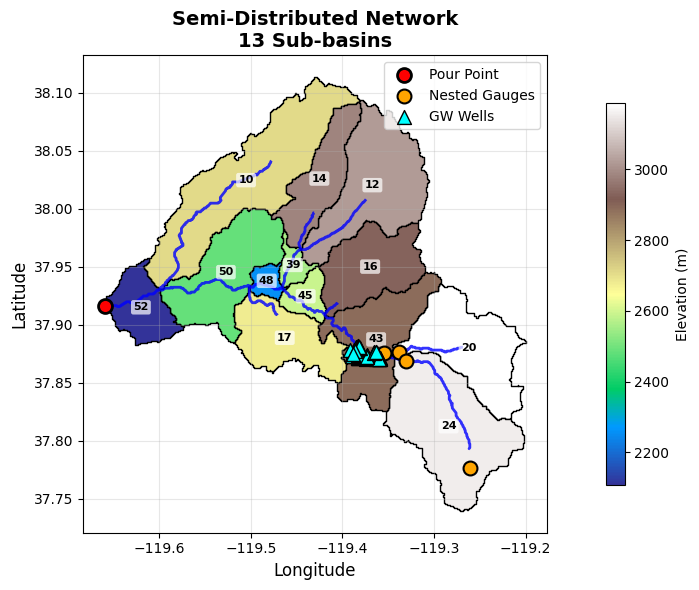

In [55]:
# Load and analyze created spatial products
basin_dir = project_dir / 'shapefiles' / 'river_basins'
network_dir = project_dir / 'shapefiles' / 'river_network'
catchment_dir = project_dir / 'shapefiles' / 'catchment'

# Load spatial data
basin_files = list(basin_dir.glob('*.shp'))
network_files = list(network_dir.glob('*.shp'))

basins_gdf = gpd.read_file(basin_files[0])
network_gdf = gpd.read_file(network_files[0])

nested_gauge_sites = pd.read_csv("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/observed_data/tuolumne/tuolmneGaugeSites.csv", 
                                 index_col=0)
nested_gauge_sites_gdf = gpd.GeoDataFrame(
    nested_gauge_sites,
    geometry=gpd.points_from_xy(nested_gauge_sites.Longitude, nested_gauge_sites.Latitude)
)
nested_gauge_sites_gdf.crs = "EPSG:4326"  # Assuming WGS84

# Project to appropriate CRS for area calculations
# For East River at Yosemite (Alberta), UTM Zone 11N is appropriate
target_crs = 'EPSG:32611'  # UTM Zone 11N
basins_projected = basins_gdf.to_crs(target_crs)

print(f"\n📋 Network Structure Summary:")
print(f"   Sub-basins (GRUs): {len(basins_gdf)}")
print(f"   Stream segments: {len(network_gdf)}")

# Calculate areas using projected geometries
total_area_m2 = basins_projected.geometry.area.sum()
total_area_km2 = total_area_m2 / 1e6
avg_gru_size_km2 = total_area_km2 / len(basins_gdf)

print(f"   Total watershed area: {total_area_km2:.1f} km²")
print(f"   Average GRU size: {avg_gru_size_km2:.1f} km²")

# Analyze GRU characteristics
if 'elevation' in basins_gdf.columns:
    print(f"   Elevation range: {basins_gdf['elevation'].min():.0f}m to {basins_gdf['elevation'].max():.0f}m")
    print(f"   Elevation gradient: {basins_gdf['elevation'].max() - basins_gdf['elevation'].min():.0f}m span")

# Stream network characteristics
if 'Length' in network_gdf.columns:
    total_length = network_gdf['Length'].sum() / 1000  # Convert to km
    print(f"   Total stream length: {total_length:.1f} km")

print(f"\n🗺️  Creating network structure visualization...")

fig, axes = plt.subplots(figsize=(12, 6))

# Left plot: Sub-basin network with elevation (use original CRS for plotting)
ax1 = axes

# import scalar mapable to make discrete colorbar
if 'elevation' in basins_gdf.columns:
    # Color by elevation
    basins_plot = basins_gdf.plot(ax=ax1, column='elevation', cmap='terrain',
                                edgecolor='black', linewidth=1, legend=True,
                                legend_kwds={'label': 'Elevation (m)', 'shrink': 0.8})
else:
    # Color by GRU ID
    basins_plot = basins_gdf.plot(ax=ax1, column='GRU_ID', cmap='viridis',
                                edgecolor='black', linewidth=1, legend=True,
                                legend_kwds={'label': 'GRU ID', 'shrink': 0.8})

# Add stream network
network_gdf.plot(ax=ax1, color='blue', linewidth=2, alpha=0.8)

# Add pour point
pour_point_gdf = gpd.read_file(pour_point_path)
pour_point_gdf.plot(ax=ax1, color='red', markersize=100, marker='o',
                   edgecolor='black', linewidth=2, zorder=5, label='Pour Point')

# add nested gauge sites
nested_gauge_sites_gdf.plot(ax=ax1, color='orange', markersize=100, marker='o',
                            edgecolor='black', linewidth=1.5, zorder=5, label='Nested Gauges')

# add groundwater wells
gw_wells.plot(ax=ax1, color='cyan', markersize=100, marker='^',
              edgecolor='black', linewidth=1, zorder=5, label='GW Wells')

# add circle with number in the center of each GRU to indicate GRU ID
for idx, row in basins_gdf.iterrows():
    centroid = row['geometry'].centroid
    ax1.text(centroid.x, centroid.y, str(row['GRU_ID']), 
             horizontalalignment='center', verticalalignment='center',
             fontsize=8, fontweight='bold', color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))

ax1.set_title(f'Semi-Distributed Network\n{len(basins_gdf)} Sub-basins', 
             fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.grid(True, alpha=0.3)


plt.legend()
plt.tight_layout()
plt.show()

## Step 3: Multi-GRU Data Pipeline
The same model-agnostic preprocessing framework now scales to multiple connected sub-basins, demonstrating CONFLUENCE's seamless transition from single-unit to multi-unit spatial modeling. The core data quality and standardization principles remain unchanged; however, spatial processing now handles distributed forcing across the GRU network and routing connectivity between sub-basins.

The same preprocessing philosophy ensures consistent data standards across spatial scales, enabling robust model intercomparison and maintaining the scientific rigor established in previous tutorials.

### Forcing data processor - Using reusable module

In [13]:
# =============================================================================
# FORCING DATA PROCESSOR - Using reusable module
# =============================================================================
from utils.custom.forcing_processor import ForcingProcessor

# Initialize the forcing processor with config
forcing_processor = ForcingProcessor(config_dict)

# Check current status of forcing data
status = forcing_processor.check_status()

FORCING DATA STATUS

Required period: 2011-10 to 2022-09
Required months: 132

📁 Raw ERA5 surface files: 0
📁 Raw ERA5 pressure files: 0

📁 Merged files: 171
   Range: 201010 to 202412

📁 Basin-averaged files: 171
   Range: 201010 to 202412

📁 SUMMA input files: 0

⚠️  Missing merged: 0
⚠️  Missing basin-averaged: 0
⚠️  Missing SUMMA input: 132


In [14]:
# =============================================================================
# STEP 3a: MERGE RAW ERA5 DATA (Surface + Pressure Level)
# =============================================================================
# Combines ERA5_surface_YYYYMM.nc + ERA5_pressureLevel137_YYYYMM.nc into ERA5_merged_YYYYMM.nc

forcing_processor.merge_era5()

✅ All merged files already exist


0

In [15]:
# =============================================================================
# STEP 3a: MERGE RAW ERA5 DATA (Surface + Pressure Level)
# =============================================================================
# Combines ERA5_surface_YYYYMM.nc + ERA5_pressureLevel137_YYYYMM.nc into ERA5_merged_YYYYMM.nc

forcing_processor.merge_era5()

✅ All merged files already exist


0

In [16]:
# =============================================================================
# STEP 3b: BASIN-AVERAGE MERGED DATA OVER CATCHMENT
# =============================================================================
# Uses CONFLUENCE's built-in EASYMORE resampler for spatial averaging

# forcing_processor.basin_average(confluence=confluence)

In [17]:
# =============================================================================
# STEP 3c: CREATE SUMMA INPUT (with optional adjustments)
# =============================================================================
# Optional: apply temperature offset and/or precipitation scaling

forcing_processor.create_summa_input(
    temp_adjustment=0.0,      # Kelvin offset (0 = no change)
    precip_multiplier=1.0,     # Scaling factor (1.0 = no change)
    recalc_longwave=True
)

# Verify final status
forcing_processor.check_status()


🔄 Creating 132 SUMMA input files...
   Recalculating longwave radiation (Dilley & O'Brien 1998)
   Progress: 12/132
   Progress: 24/132
   Progress: 36/132
   Progress: 48/132
   Progress: 60/132
   Progress: 72/132
   Progress: 84/132
   Progress: 96/132
   Progress: 108/132
   Progress: 120/132
   Progress: 132/132
✅ SUMMA input creation complete: 132/132
FORCING DATA STATUS

Required period: 2011-10 to 2022-09
Required months: 132

📁 Raw ERA5 surface files: 0
📁 Raw ERA5 pressure files: 0

📁 Merged files: 171
   Range: 201010 to 202412

📁 Basin-averaged files: 171
   Range: 201010 to 202412

📁 SUMMA input files: 132
   Range: 201110 to 202209

⚠️  Missing merged: 0
⚠️  Missing basin-averaged: 0
⚠️  Missing SUMMA input: 0


{'required_period': '2011-10 to 2022-09',
 'required_months': 132,
 'raw_surface_count': 0,
 'raw_pressure_count': 0,
 'merged_count': 171,
 'basin_avg_count': 171,
 'summa_input_count': 132,
 'missing_merged': [],
 'missing_basin_avg': [],
 'missing_summa': []}

### Gather observed data

In [18]:
# Execute streamflow data processing 
confluence.managers['data'].process_observed_data()
print("✅ Streamflow validation data ready")

2026-02-26 16:43:55 ● Processing observed data
2026-02-26 16:43:55 ● Processing USGS streamflow data directly from API
2026-02-26 16:43:55 ● Retrieving discharge data for station 11274790
2026-02-26 16:43:55 ● Time period: 2011-10-01 to 2026-02-25
2026-02-26 16:43:55 ● Converting from cfs to cms using factor: 0.0283168
2026-02-26 16:43:55 ● Using formatted start date: 2011-10-01
2026-02-26 16:43:55 ● Using formatted end date: 2026-02-25
2026-02-26 16:43:55 ● Fetching data from: https://nwis.waterservices.usgs.gov/nwis/dv/?site=11274790&format=rdb&parameterCd=00060&startDT=2011-10-01&endDT=2026-02-25
2026-02-26 16:44:25 ● Error fetching data from USGS API: HTTPSConnectionPool(host='nwis.waterservices.usgs.gov', port=443): Read timed out. (read timeout=30)
2026-02-26 16:44:25 ● Trying fallback URL: https://waterservices.usgs.gov/nwis/dv/?site=11274790&format=rdb&parameterCd=00060&startDT=2011-10-01&endDT=2026-02-25
2026-02-26 16:44:27 ● Processed streamflow data saved to: /scratch/dlhoga

### Model Agnostic preprocessing

In [19]:
# Check if forcing data was copied, otherwise acquire
forcing_dir = project_dir / 'forcing' / 'merged_data'
if not forcing_dir.exists() or len(list(forcing_dir.glob('*.nc'))) == 0:
    # confluence.managers['data'].acquire_forcings()
    print("✅ Forcing acquisition complete (simulated)")

In [20]:
# Execute model-agnostic preprocessing
confluence.managers['data'].run_model_agnostic_preprocessing()
print("✅ Multi-GRU preprocessing complete")

2026-02-26 16:44:27 ● Starting model-agnostic preprocessing
2026-02-26 16:44:27 ● Running geospatial statistics
2026-02-26 16:44:27 ● Starting geospatial statistics calculation
2026-02-26 16:44:27 ● Soil statistics already calculated: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/shapefiles/catchment_intersection/with_soilgrids/catchment_with_soilclass.shp
2026-02-26 16:44:27 ● Land statistics already calculated: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/shapefiles/catchment_intersection/with_landclass/catchment_with_landclass.shp
2026-02-26 16:44:27 ● Elevation statistics already calculated: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/shapefiles/catchment_intersection/with_dem/catchment_with_dem.shp
2026-02-26 16:44:27 ● Geospatial statistics completed: 3/3 steps skipped, 0/3 steps executed
2026-02-26 16:44:27 ● Running forcing resampling
2026-02-26 16:44:27 ● Starting forcing data resampling process
2026-02-26 16:44:27 ● Creating ERA5 shapefile
202

In [21]:
# =============================================================================
# PROTECT CUSTOM PARAMETER FILES BEFORE PREPROCESSING
# =============================================================================
# IMPORTANT: Backup custom parameter files before model preprocessing,
# because confluence.managers['model'].preprocess_models() calls
# copy_base_settings() which would overwrite our custom configurations!

print("🔒 Backing up custom parameter files before preprocessing...")
backup_dir = project_settings_dir / "backup_custom_config"
backup_dir.mkdir(parents=True, exist_ok=True)

# Backup the three critical parameter files
critical_files = [
    "modelDecisions.txt",
    "localParamInfo.txt", 
    "basinParamInfo.txt"
]

for fname in critical_files:
    src = project_settings_dir / fname
    dst = backup_dir / fname
    if src.exists():
        shutil.copy(src, dst)
        print(f"   ✓ Backed up {fname}")
    else:
        print(f"   ⚠ {fname} not found (will be created during preprocessing)")

# ============= Execute model-specific preprocessing =============
# This step will copy base settings and create forcing files, initial conditions, etc.
# But it WILL overwrite our custom parameter files, so we backed them up above!
confluence.managers['model'].preprocess_models()
print("✅ Model-specific preprocessing complete")

# ============= RESTORE CUSTOM PARAMETER FILES AFTER PREPROCESSING =============
print("\n🔓 Restoring custom parameter files after preprocessing...")
for fname in critical_files:
    src = backup_dir / fname
    dst = project_settings_dir / fname
    if src.exists():
        shutil.copy(src, dst)
        print(f"   ✓ Restored {fname}")

print(f"\n✓ Custom parameters protected and restored in {project_settings_dir}")
print(f"✓ Base settings remain unchanged in {base_settings_dir}")

🔒 Backing up custom parameter files before preprocessing...
   ✓ Backed up modelDecisions.txt
   ✓ Backed up localParamInfo.txt
   ✓ Backed up basinParamInfo.txt
2026-02-26 16:44:27 ● Starting model-specific preprocessing
2026-02-26 16:44:27 ● Starting SUMMA spatial preprocessing
2026-02-26 16:44:27 ● Starting memory-efficient temperature lapse rate and data step application
2026-02-26 16:44:27 ● Converting /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/shapefiles/catchment_intersection/with_forcing/Tuolumne_River_ERA5_intersected_shapefile.shp to CSV format
2026-02-26 16:44:27 ● Successfully created /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/shapefiles/catchment_intersection/with_forcing/Tuolumne_River_ERA5_intersected_shapefile.csv
2026-02-26 16:44:28 ● Loading topology data...
2026-02-26 16:44:28 ● Loaded topology data: 22 rows, 0.18 MB
2026-02-26 16:44:28 ● Found 171 forcing files to process
2026-02-26 16:44:28 ● Pre-calculating lapse rate corrections...
2026-

/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/utils/models/mizuroute_utils.py:363: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = shp_river.geometry.distance(pour_point_geom)


## Step 4: Streamlined Semi-Distributed Model Execution
The same SUMMA process-based physics now executes across multiple connected sub-basins, representing an advance in spatial modeling complexity. This integration of distributed runoff generation with explicit network routing demonstrates how the same computational framework scales from single-unit to multi-unit watershed simulation while maintaining physical realism and computational efficiency. The same workflow orchestration ensures robust execution across this increased complexity while mizuRoute integration transforms the distributed runoff into realistic streamflow with routing delays and channel storage effects.

In [22]:
# Ensure parameter snapshots are saved inside the experiment folder
experiment_dir = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_updates['DOMAIN_NAME']}" / "simulations" / name
outputeControl_file = "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_base_settings/SUMMA/outputControl.txt"
parameters_dir = experiment_dir / "parameters"
parameters_dir.mkdir(parents=True, exist_ok=True)
shutil.copy(localParamInfo_file, parameters_dir / "localParamInfo.txt")
shutil.copy(basinParamInfo_file, parameters_dir / "basinParamInfo.txt")
shutil.copy(outputeControl_file, project_settings_dir / "outputControl.txt")

PosixPath('/scratch/dlhogan/ess-project-data/domain_Tuolumne_River/settings/SUMMA/outputControl.txt')

In [23]:
# Execute the semi-distributed model system

confluence.managers['model'].run_models()


2026-02-26 16:48:08 ● Starting model runs
2026-02-26 16:48:08 ● Running model: SUMMA
2026-02-26 16:48:08 ● Starting SUMMA run
2026-02-26 17:12:16 ● SUMMA run completed successfully
2026-02-26 17:12:16 ● Fixing SUMMA time precision for mizuRoute compatibility
2026-02-26 17:12:16 ● mizuRoute run failed with error: Command '/home/dlhogan/tools/src/mizuRoute/route/bin/mizuroute.exe /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/settings/mizuRoute/mizuroute.control' returned non-zero exit status 127.
2026-02-26 17:12:16 ● Error running model SUMMA: Command '/home/dlhogan/tools/src/mizuRoute/route/bin/mizuroute.exe /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/settings/mizuRoute/mizuroute.control' returned non-zero exit status 127.
2026-02-26 17:12:16 ● Traceback (most recent call last):
  File "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/utils/models/model_manager.py", line 435, in run_models
    mizuroute_runner.run_mizuroute()
  File "/home/dlhogan/project

CalledProcessError: Command '/home/dlhogan/tools/src/mizuRoute/route/bin/mizuroute.exe /scratch/dlhogan/ess-project-data/domain_Tuolumne_River/settings/mizuRoute/mizuroute.control' returned non-zero exit status 127.

In [32]:

routing_dir = project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "mizuRoute"
routing_files = list(routing_dir.glob("*.nc"))
if not routing_files:
    mizuRoute_run_status = False
    print("⚠️  mizuRoute likely broke - run linear reservoir routing instead")
else:
    mizuRoute_run_status = True
    print("✅ model completed successfully")


⚠️  mizuRoute likely broke - run linear reservoir routing instead


### Step 4b: Alternative Cascade of Linear Reservoir Routing

In [33]:
import numpy as np
from collections import deque

def route_modeled_outflows_cascade(Q_modeled, downstream, length_m, slope, dt,
                                   K=None,
                                   K_scale=1.0,
                                   mannings_n=0.04,
                                   depth_m=0.4,
                                   n_cascade=2,
                                   delay_steps=None):
    """
    Route modeled outflows from sub-basins through a directed network where each reach
    is represented as a cascade of linear reservoirs.
    
    Inputs:
      - Q_modeled: (n_reach, n_t) array of modeled outflow (m3/s) — treated as inflow to routing element.
      - downstream: length-n_reach array of downstream indices (-1 for global outlet).
      - length_m, slope: arrays length n_reach.
      - dt: timestep in seconds.
      - K: optional array of reservoir timescale (seconds) per reach. If None, estimate via Manning.
      - K_scale: scalar multiplier applied to K (easy tuning).
      - mannings_n, depth_m: used if K is None (defaults reasonable for mountain streams).
      - n_cascade: scalar or array (# of linear reservoirs per reach). can be int or array-like.
      - delay_steps: optional integer-array per reach specifying a pure integer-step delay (in time-steps)
                     to apply instead of/alongside cascade. If provided, it's used as an extra FIFO delay.
    Returns:
      - Q_routed: (n_reach, n_t) routed outflow time series at the downstream end of each reach.
      - K_used: array of K actually used (seconds).
    """
    Q = np.array(Q_modeled, dtype=float)
    n_reach, n_t = Q.shape

    # n_cascade handling
    if np.isscalar(n_cascade):
        n_cascade_arr = np.full(n_reach, int(n_cascade), dtype=int)
    else:
        n_cascade_arr = np.array(n_cascade, dtype=int)

    # estimate K if not provided
    if K is None:
        K = np.zeros(n_reach, dtype=float)
        for i in range(n_reach):
            Si = max(slope[i], 1e-9)
            R = max(depth_m, 0.01)
            V = (1.0 / mannings_n) * (R ** (2.0/3.0)) * np.sqrt(Si)
            V = max(V, 1e-6)
            K[i] = max(length_m[i] / V, 1.0)
    else:
        K = np.array(K, dtype=float)

    K_used = K * float(K_scale)
    # avoid zeros
    K_used = np.maximum(K_used, 1e-6)

    # build topo ordering
    indeg = np.zeros(n_reach, dtype=int)
    for i, d in enumerate(downstream):
        if 0 <= d < n_reach:
            indeg[d] += 1
    q = deque([i for i in range(n_reach) if indeg[i] == 0])
    topo = []
    while q:
        u = q.popleft()
        topo.append(u)
        d = downstream[u]
        if 0 <= d < n_reach:
            indeg[d] -= 1
            if indeg[d] == 0:
                q.append(d)
    if len(topo) != n_reach:
        raise ValueError("Network invalid or contains cycle.")

    # Precompute per-reservoir alpha for each reach
    alphas = np.zeros(n_reach, dtype=float)
    for i in range(n_reach):
        m = max(1, n_cascade_arr[i])
        K_r = K_used[i] / m
        alphas[i] = np.exp(-dt / K_r)

    # If delay_steps provided, create buffers
    if delay_steps is not None:
        delay_steps = np.array(delay_steps, dtype=int)
        buffers = [deque([0.0]*(int(delay_steps[i]) + 1), maxlen=int(delay_steps[i]) + 1)
                   for i in range(n_reach)]
    else:
        buffers = None

    # storage for cascade state: Q_prev for each reservoir (use max cascade length)
    max_m = int(np.max(n_cascade_arr))
    Q_prev_res = np.zeros((n_reach, max_m), dtype=float)

    Q_routed = np.zeros_like(Q)

    # main loop: each timestep, treat Q_modeled as the inflow to the first reservoir of the reach
    for ti in range(n_t):
        # start inflow with modeled outflow at this timestep
        inflow = Q[:, ti].copy()

        # if delay buffers used, first pop from them to form inflow, but also push local modeled inflow into them
        if buffers is not None:
            # for causal consistency, first add current modeled inflow to buffers then set inflow to popped values
            for i in range(n_reach):
                buffers[i].append(inflow[i])
            # now replace inflow with buffer pop
            inflow = np.array([buffers[i].popleft() for i in range(n_reach)])

        # route in topo order (so upstream contributions reach downstream inflow same timestep)
        for g in topo:
            m = n_cascade_arr[g]
            a = alphas[g]
            # push inflow through cascade of m linear reservoirs (outflow of each reservoir becomes inflow to next)
            I = inflow[g]
            for r in range(m):
                Q_new = a * Q_prev_res[g, r] + (1.0 - a) * I
                Q_prev_res[g, r] = Q_new
                I = Q_new
            Q_routed[g, ti] = I  # final reservoir outflow

            # add routed outflow to downstream inflow for this timestep (causal)
            d = downstream[g]
            if 0 <= d < n_reach:
                inflow[d] += Q_routed[g, ti]

    return Q_routed, K_used

In [34]:
def map_downstream_ids_to_indices(downstream_ids, reach_ids):
    """
    Map downstream values (GRU IDs) to zero-based indices matching reach_ids order.
    - downstream_ids: array length n_reach, values are GRU IDs (or -1 for outlet).
    - reach_ids:     array length n_reach, reach ID for each row (must match Q_modeled order).
    Returns an int array downstream_idx of same length with values in [-1..n_reach-1].
    """
    downstream_ids = np.asarray(downstream_ids)
    reach_ids = np.asarray(reach_ids)
    if reach_ids.shape[0] != downstream_ids.shape[0]:
        raise ValueError("reach_ids must be same length as downstream_ids / n_reach")

    id_to_idx = {rid: i for i, rid in enumerate(reach_ids)}
    downstream_idx = np.full_like(downstream_ids, fill_value=-1, dtype=int)

    missing = set()
    for i, d in enumerate(downstream_ids):
        if d == -1:
            downstream_idx[i] = -1
            continue
        # If downstream value equals this reach's own id, treat as outlet/self -> -1
        if d == reach_ids[i]:
            downstream_idx[i] = -1
            continue
        if d in id_to_idx:
            downstream_idx[i] = id_to_idx[d]
        else:
            # not found in reach_ids -> set to -1 (treat as outlet) and record for debug
            downstream_idx[i] = -1
            missing.add(d)

    if missing:
        print("Warning: these downstream IDs were not found in reach_ids and were set to -1:", missing)
    return downstream_idx


#### Apply routing scheme.

In [35]:
# Load observed streamflow (same as lumped model for direct comparison)
obs_path = project_dir / "observations" / "streamflow" / "preprocessed" / f"{config_dict['DOMAIN_NAME']}_streamflow_processed.csv"
obs_df = pd.read_csv(obs_path, parse_dates=['datetime'])
obs_df.set_index('datetime', inplace=True)

if not mizuRoute_run_status:
    # Load semi-distributed simulation from SUMMA
    summa_sim_dir = project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "SUMMA"
    summa_sim_files = list(summa_sim_dir.glob('*.nc'))

    # Load SUMMA output
    summa_sim_ds = xr.open_dataset(summa_sim_files[0])

    # Load network topology
    topology_file = project_dir / "settings" / "mizuRoute" / "topology.nc"
    topology_ds = xr.open_dataset(topology_file)

    # Extract discharge time series
    Q_modeled = summa_sim_ds['averageRoutedRunoff'].transpose('gru', 'time').values # (n_reach, n_time)

    # Convert from m/s to m3/s by multiplying by area
    Q_modeled =  Q_modeled * topology_ds["area"].values[:, np.newaxis]  # (n_reach, n_time)

    # --- Extract topology & geometry ---
    downstream = map_downstream_ids_to_indices(topology_ds["downSegId"].values.astype(int), topology_ds["segId"].values.astype(int))
    length_m   = topology_ds["length"].values
    slope      = topology_ds["slope"].values

    # --- Time step (seconds) ---
    time = summa_sim_ds["time"].values
    # compute dt from first two timestamps (assumes regular spacing)
    dt = (np.diff(time).astype("timedelta64[s]")[0]).astype(int)
    print(f"Simulation time step: {dt} seconds")

    Q_routed, K_used = route_modeled_outflows_cascade(
    Q_modeled=Q_modeled,
    downstream=downstream,
    length_m=length_m,
    slope=slope,
    dt=dt,
    n_cascade=2,
    K_scale=10.0
    )

    # Identify outlet hydrograph
    outlet_idx = np.where(downstream == -1)[0][0]
    Q_outlet = Q_routed[outlet_idx, :]

    routing_da = xr.DataArray(
        Q_routed,
        dims=("gru", "time"),
        coords={"gru": summa_sim_ds["gru"], "time": summa_sim_ds["time"].values},
        name="IRFroutedRunoff"
    )

    routing_ds = routing_da.to_dataset()

    # add in Q_outlet as another gru
    routing_ds['Q_outlet'] = (('time',), Q_outlet)

Simulation time step: 3599 seconds


Rerouting example...
K used per GRU (s): [ 2940.45523645  4214.3165475   1191.0715629   1477.7033747
  5714.32549659  1124.9099331  12004.84770967  3232.94108664
  1222.31317029   824.34155921  1193.93106101  3285.09300913
  6099.41937474]


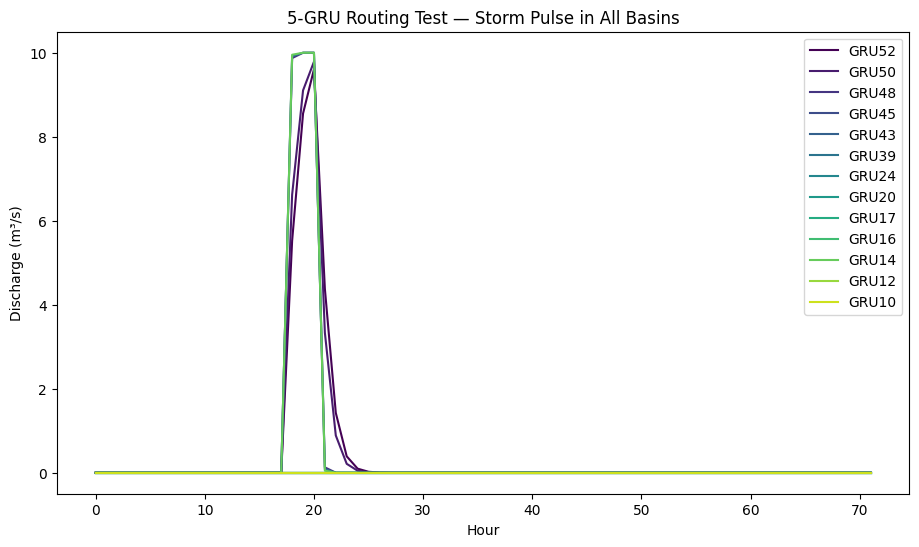

Outlet peak flow: 9.604490052169822
Outlet peak hour: 20


In [36]:
print("Rerouting example...")
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# ---------- Network topology ----------
n_reach = 13              

downstream = map_downstream_ids_to_indices(
    topology_ds["downSegId"].values.astype(int),
    topology_ds["segId"].values.astype(int)
)
length_m   = topology_ds["length"].values
slope      = topology_ds["slope"].values

# ---------- Create inflow time series ----------
dt = 3600                     # 1-hour
n_t = 24*3                    # 3 days
# initialize with baseflows increasing downstream for the 13 GRUs
Q_modeled = np.zeros((n_reach, n_t))

# Add a 3-hour, 10 m³/s storm pulse to last 3 basins at hour 18
Q_modeled[-3,18:21] = 10.0


# ---------- Run routing ----------
Q_routed, K_used = route_modeled_outflows_cascade(
    Q_modeled,
    downstream=downstream,
    length_m=length_m,
    slope=slope,
    dt=dt,
    n_cascade=2,
    K_scale=1.0
)

# ---------- Diagnostics ----------
print("K used per GRU (s):", K_used)

time = np.arange(n_t)
plt.figure(figsize=(11,6))
cmap = plt.get_cmap("viridis")
for i in range(n_reach):
    plt.plot(time, Q_routed[i], label=f"GRU{topology_ds['segId'].values[i]}", color=cmap(i/n_reach))
plt.xlabel("Hour")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.title("5-GRU Routing Test — Storm Pulse in All Basins")
plt.show()

print("Outlet peak flow:", Q_routed[0].max())
print("Outlet peak hour:", np.argmax(Q_routed[0]))


## Step 5: Evaluation and Performance Comparison

/tmp/ipykernel_386209/1849881785.py:97: RuntimeWarning: invalid value encountered in scalar divide
  obs_com = np.sum(days * obs_vals[~np.isnan(obs_vals)]) / np.sum(obs_vals[~np.isnan(obs_vals)])



=== TIMING DIAGNOSTICS ===
Mean timing offset: 41 days (negative = early)
Peak month: Obs=5, Sim=8
NSE (post spin-up): -1.436


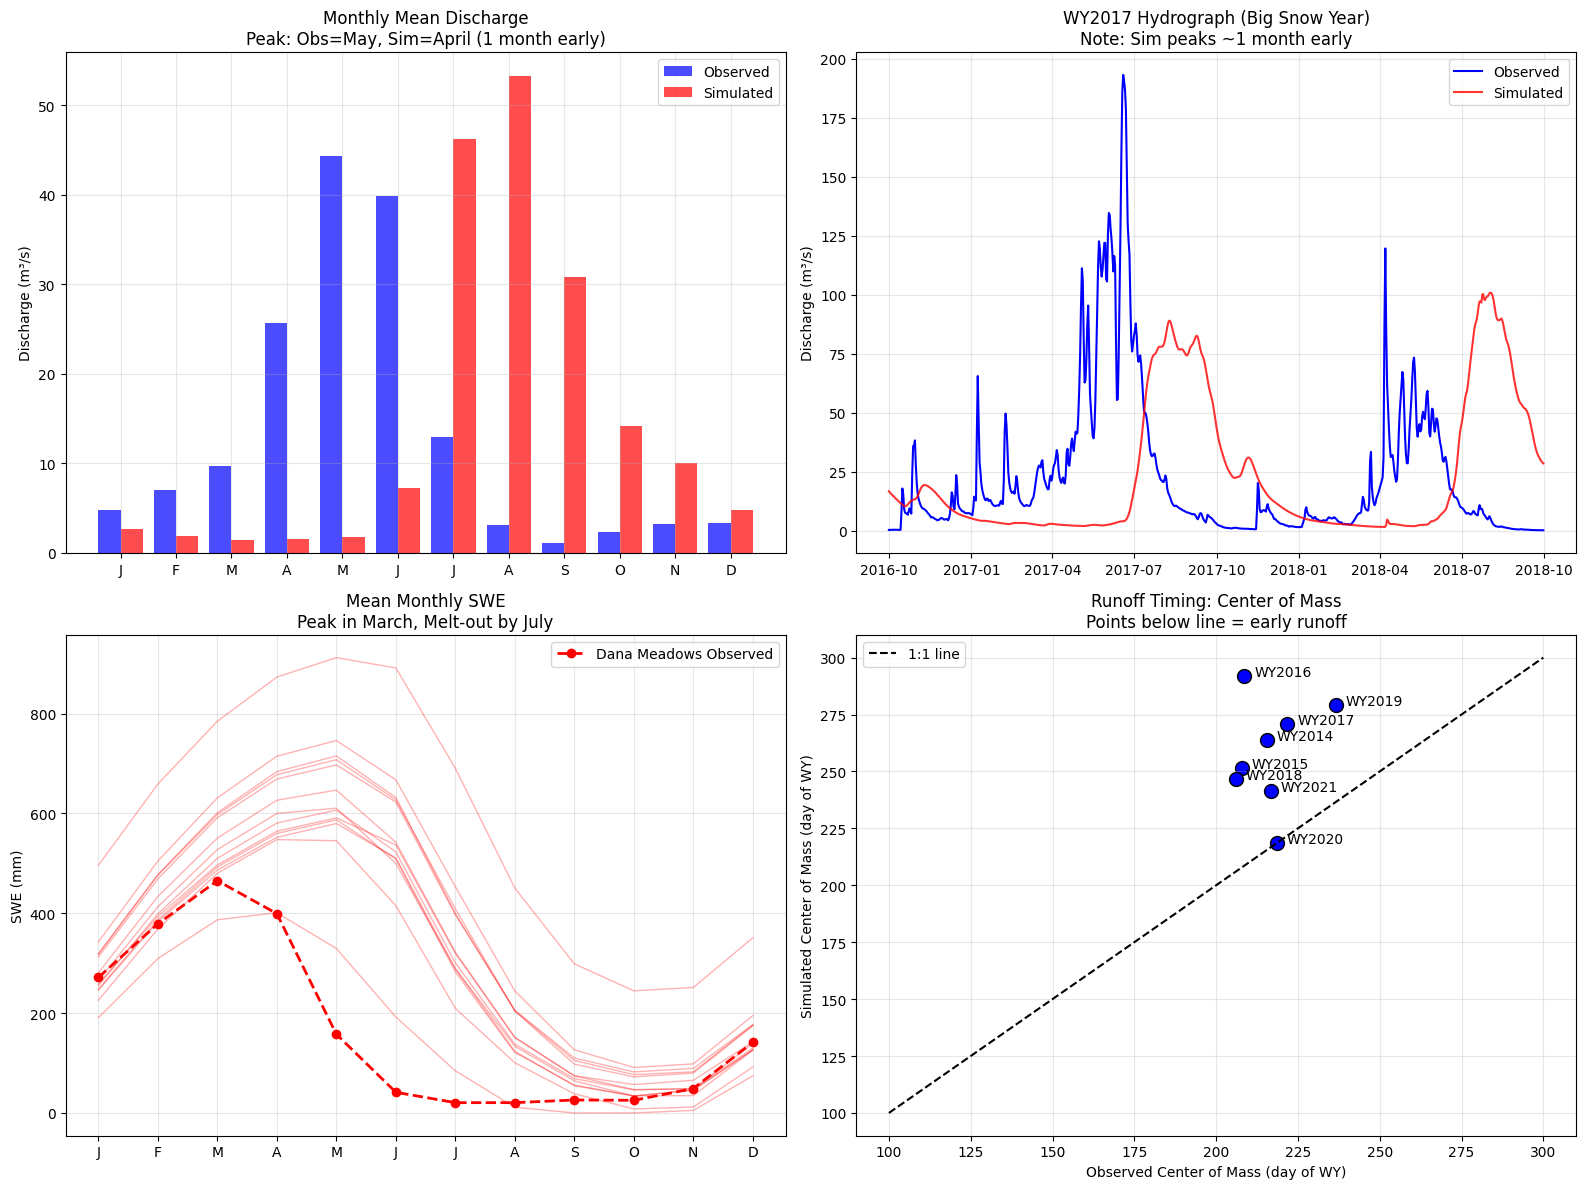

In [50]:
summa_dir = project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "SUMMA"
sim_ds = xr.open_dataset(list(summa_dir.glob("*_timestep.nc"))[0])
save = False

# Get basin area
shp_path = project_dir / "shapefiles" / "catchment" / f"{config_dict['DOMAIN_NAME']}_HRUs_GRUs.shp"
gdf = gpd.read_file(shp_path).to_crs('EPSG:32611')
basin_area = gdf.geometry.area.sum()

# Calculate discharge
runoff =routing_ds['Q_outlet']# sim_ds['scalarTotalRunoff'].squeeze()
discharge = runoff #* basin_area  # m³/s

# Load observations
obs_path = project_dir / "observations" / "streamflow" / "preprocessed" / f"{config_dict['DOMAIN_NAME']}_streamflow_processed.csv"
obs_df = pd.read_csv(obs_path, parse_dates=['datetime'])
obs_df.set_index('datetime', inplace=True)

# Align to common period (skip first year for spin-up)
start = '2013-10-01'
end = '2022-09-30'
sim_daily = discharge.resample(time='D').mean().sel(time=slice(start, end))
obs_daily = obs_df['discharge_cms'].resample('D').mean().loc[start:end]

# Create figure
fig = plt.figure(figsize=(16, 12))

# 1. Monthly climatology comparison
ax1 = fig.add_subplot(2, 2, 1)
sim_monthly = sim_daily.groupby('time.month').mean()
obs_monthly = obs_daily.groupby(obs_daily.index.month).mean()
months = range(1, 13)
ax1.bar([m-0.2 for m in months], [float(obs_monthly.loc[m]) for m in months], 
        width=0.4, label='Observed', color='blue', alpha=0.7)
ax1.bar([m+0.2 for m in months], [float(sim_monthly.sel(month=m)) for m in months], 
        width=0.4, label='Simulated', color='red', alpha=0.7)
ax1.set_xticks(months)
ax1.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax1.set_ylabel('Discharge (m³/s)')
ax1.set_title('Monthly Mean Discharge\nPeak: Obs=May, Sim=April (1 month early)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Water year 2017 (big snow year) hydrograph
ax2 = fig.add_subplot(2, 2, 2)
wy2017_sim = sim_daily.sel(time=slice('2016-10-01', '2018-09-30'))
wy2017_obs = obs_daily.loc['2016-10-01':'2018-09-30']
ax2.plot(wy2017_obs.index, wy2017_obs.values, 'b-', label='Observed', lw=1.5)
ax2.plot(pd.to_datetime(wy2017_sim.time.values), wy2017_sim.values, 'r-', label='Simulated', lw=1.5, alpha=0.8)
ax2.set_ylabel('Discharge (m³/s)')
ax2.set_title('WY2017 Hydrograph (Big Snow Year)\nNote: Sim peaks ~1 month early')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. SWE comparison with Tuolumne Meadows if available
ax3 = fig.add_subplot(2, 2, 3)
swe = sim_ds['scalarSWE'].squeeze().resample(time='D').mean()
tuolumne_meadows = pd.read_csv(f"/scratch/dlhogan/ess-project-data/domain_{config_dict['DOMAIN_NAME']}_lumped/observations/snow/TUM_TUOLUMNE_MEADOWS_cdec_obs.csv", parse_dates=['datetime'], index_col='datetime')
tuolumne_meadows_swe = tuolumne_meadows['SWE']*25.4
# filter values 
# filter extreme values
tuolumne_meadows_swe = tuolumne_meadows_swe[(tuolumne_meadows_swe < 2000) & (tuolumne_meadows_swe >= 0)]
tuolumne_meadows_swe_monthly = tuolumne_meadows_swe.groupby(tuolumne_meadows_swe.index.month).mean()
# Plot multi-year average SWE cycle
swe_monthly = swe.sel(time=slice(start, end)).groupby('time.month').mean()
for hru in sim_ds['hru'].values:
    ax3.plot(months, [float(swe_monthly.sel(hru=hru, month=m)) for m in months], 'r-', lw=1, alpha=0.3)
# ax3.plot(months, [float(swe_monthly.sel(month=m)) for m in months], 'b-o', lw=2, label='Simulated SWE')
ax3.plot(months, tuolumne_meadows_swe_monthly.values, 'r--o', lw=2, label='Dana Meadows Observed')
ax3.set_xticks(months)
ax3.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax3.set_ylabel('SWE (mm)')
ax3.set_title('Mean Monthly SWE\nPeak in March, Melt-out by July')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. Timing metrics by year
ax4 = fig.add_subplot(2, 2, 4)
timing_data = []
for year in range(2012, 2022):
    wy_start = f'{year-1}-10-01'
    wy_end = f'{year}-09-30'
    
    sim_wy = sim_daily.sel(time=slice(wy_start, wy_end))
    obs_wy = obs_daily.loc[wy_start:wy_end]
    
    # Find center of mass (timing metric)
    sim_vals = sim_wy.values
    obs_vals = obs_wy.values
    
    days = np.arange(len(sim_vals))
    if np.sum(sim_vals) > 0:
        sim_com = np.sum(days * sim_vals) / np.sum(sim_vals)
    else:
        sim_com = np.nan
        
    obs_com = np.sum(days * obs_vals[~np.isnan(obs_vals)]) / np.sum(obs_vals[~np.isnan(obs_vals)])
    
    timing_data.append({'year': year, 'sim_com': sim_com, 'obs_com': obs_com})

timing_df = pd.DataFrame(timing_data)
ax4.scatter(timing_df['obs_com'], timing_df['sim_com'], s=100, c='blue', edgecolor='black')
ax4.plot([100, 300], [100, 300], 'k--', label='1:1 line')
for _, row in timing_df.iterrows():
    ax4.annotate(f"WY{int(row['year'])}", (row['obs_com']+3, row['sim_com']))
ax4.set_xlabel('Observed Center of Mass (day of WY)')
ax4.set_ylabel('Simulated Center of Mass (day of WY)')
ax4.set_title('Runoff Timing: Center of Mass\nPoints below line = early runoff')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
if save:
    plt.savefig('/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/plots/timing_diagnostic.png', dpi=150)
    print("Saved: timing_diagnostic.png")

# Print summary statistics
print("\n=== TIMING DIAGNOSTICS ===")
print(f"Mean timing offset: {float(timing_df['sim_com'].mean() - timing_df['obs_com'].mean()):.0f} days (negative = early)")
print(f"Peak month: Obs={obs_monthly.idxmax()}, Sim={int(sim_monthly.argmax())+1}")

# Calculate NSE excluding spin-up
common_idx = pd.to_datetime(sim_daily.time.values)
obs_aligned = obs_daily.reindex(common_idx)
valid = ~obs_aligned.isna()
sim_v = sim_daily.values[valid]
obs_v = obs_aligned.values[valid]
nse = 1 - np.sum((obs_v - sim_v)**2) / np.sum((obs_v - np.mean(obs_v))**2)
print(f"NSE (post spin-up): {nse:.3f}")

sim_ds.close()
plt.show()

In [ ]:
# Load observed streamflow data
obs_path = project_dir / "observations" / "streamflow" / "preprocessed" / f"{config_dict['DOMAIN_NAME']}_streamflow_processed.csv"
obs_df = pd.read_csv(obs_path, parse_dates=['datetime'])
obs_df.set_index('datetime', inplace=True)
    
# Load simulated streamflow from mizuRoute
summa_dir = project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "SUMMA"
routing_dir = project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "mizuRoute"
routing_files = list(routing_dir.glob("*.nc"))


In [ ]:
# Load semi-distributed simulation from mizuRoute
routing_dir = confluence.project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "mizuRoute"
routing_files = list(routing_dir.glob("*.nc"))
if routing_files:
    # Load mizuRoute output
    routing_ds = xr.open_dataset(routing_files[0])
    
    # Extract streamflow variable (typically IRFroutedRunoff)
    
    sim_streamflow = routing_ds['IRFroutedRunoff']
    sim_df = sim_streamflow.to_pandas()    
    routing_ds.close()

else:
    sim_ds = xr.open_dataset(list(summa_dir.glob("*_timestep.nc"))[0])
    shp_file = gpd.read_file(str(project_dir / "shapefiles" / "catchment" / f"{config_dict['DOMAIN_NAME']}_HRUs_{config_dict['DOMAIN_DISCRETIZATION']}.shp"))
    shp_area = shp_file['GRU_area'].values[1]
    sim_ds['scalarTotalRunoff'] = sim_ds['scalarTotalRunoff'] * shp_area
    sim_streamflow = sim_ds['scalarTotalRunoff']    
    sim_df = sim_streamflow.to_pandas()
    # Calculate discharge
    
    sim_ds.close()

else:
    print(f"⚠️  mizuRoute output not found")
    print(f" Using linear reservoir routing instead...")
    if config_dict['SIM_REACH_ID'] == routing_ds.gru.values[-1]:
        reach_id = int(config_dict.get('SIM_REACH_ID', routing_ds.gru.values[-1]))
    else:
        reach_id = routing_ds.gru.values[-1]

    # Find segment index for outlet
    segment_indices = np.where(routing_ds.gru.values == reach_id)[0]
    sim_df = routing_ds['Q_outlet'].to_pandas()

In [ ]:
# # may be obsolete
# if routing_files:
#     # Load mizuRoute network output
#     routing_ds = xr.open_dataset(routing_files[0])
    
#     # Extract outlet streamflow (typically the downstream-most segment)
#     if 'IRFroutedRunoff' in routing_ds.data_vars:
#         # Find outlet segment (could be identified by SIM_REACH_ID or maximum downstream position)
#         reach_id = int(config_dict.get('SIM_REACH_ID', routing_ds.reachID.values[-1]))
        
#         # Find segment index for outlet
#         segment_indices = np.where(routing_ds.reachID.values == reach_id)[0]
        
#         if len(segment_indices) > 0:
#             segment_idx = segment_indices[0]
#             sim_streamflow = routing_ds['IRFroutedRunoff'].isel(seg=segment_idx)
#             sim_df = sim_streamflow.to_pandas()
                        
#         else:
#             print(f"⚠️  Outlet segment {reach_id} not found")
#             sim_df = None
#     else:
#         print(f"⚠️  Streamflow variable not found in routing output")
#         sim_df = None
        
#     routing_ds.close()

In [ ]:

# =============================================================================
# STREAMFLOW PERFORMANCE EVALUATION
# =============================================================================

print(f"\n Streamflow Performance Assessment...")

# Align data to common period
start_date = max(obs_df.index.min(), sim_df.index.min())
end_date = min(obs_df.index.max(), sim_df.index.max())

# Skip initial spinup period
start_date = start_date + pd.DateOffset(months=6)

print(f"   Evaluation period: {start_date} to {end_date}")
print(f"   Duration: {(end_date - start_date).days} days")

# Filter to common period and resample to daily
obs_daily = obs_df['discharge_cms'].resample('D').mean().loc[start_date:end_date]
sim_daily = sim_df.resample('D').mean().loc[start_date:end_date]

# Ensure sim_daily is a Series (in case it's a DataFrame with one column)
if isinstance(sim_daily, pd.DataFrame):
    if sim_daily.shape[1] == 1:
        sim_daily = sim_daily.iloc[:, 0]  # Take the first (and likely only) column
    else:
        print(f"⚠️  sim_daily has {sim_daily.shape[1]} columns. Using the first column.")
        print(f"   Available columns: {list(sim_daily.columns)}")
        sim_daily = sim_daily.iloc[:, 0]

# Remove any remaining NaN values
valid_mask = ~(obs_daily.isna() | sim_daily.isna())
obs_valid = obs_daily[valid_mask]
sim_valid = sim_daily[valid_mask]    
print(f"   Valid paired observations: {len(obs_valid)} days")

# Calculate comprehensive performance metrics
print(f"\n📈 Streamflow Performance Metrics:")

# Basic statistics
rmse = np.sqrt(((obs_valid - sim_valid) ** 2).mean())
bias = (sim_valid - obs_valid).mean()
mae = np.abs(obs_valid - sim_valid).mean()

# Relative metrics
pbias = 100 * bias / obs_valid.mean()

# Nash-Sutcliffe Efficiency
nse = 1 - ((obs_valid - sim_valid) ** 2).sum() / ((obs_valid - obs_valid.mean()) ** 2).sum()

# Kling-Gupta Efficiency  
r = obs_valid.corr(sim_valid)
alpha = sim_valid.std() / obs_valid.std()
beta = sim_valid.mean() / obs_valid.mean()
kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# Display performance metrics
print(f"   📊 RMSE: {rmse:.2f} m³/s")
print(f"   📊 Bias: {bias:+.2f} m³/s ({pbias:+.1f}%)")
print(f"   📊 MAE: {mae:.2f} m³/s")
print(f"   📊 Correlation (r): {r:.3f}")
print(f"   📊 Nash-Sutcliffe (NSE): {nse:.3f}")
print(f"   📊 Kling-Gupta (KGE): {kge:.3f}")

# Hydrologic signature analysis
print(f"\n🌊 Hydrologic Signature Analysis:")

# Flow statistics
obs_q95 = obs_valid.quantile(0.95)  # High flows
sim_q95 = sim_valid.quantile(0.95)
obs_q05 = obs_valid.quantile(0.05)  # Low flows  
sim_q05 = sim_valid.quantile(0.05)

print(f"   High flows (Q95): Obs={obs_q95:.1f}, Sim={sim_q95:.1f} m³/s")
print(f"   Low flows (Q05): Obs={obs_q05:.1f}, Sim={sim_q05:.1f} m³/s")

# Seasonal timing
obs_monthly = obs_valid.groupby(obs_valid.index.month).mean()
sim_monthly = sim_valid.groupby(sim_valid.index.month).mean()
peak_month_obs = obs_monthly.idxmax()
peak_month_sim = sim_monthly.idxmax()

print(f"   Peak flow timing: Obs=Month {peak_month_obs}, Sim=Month {peak_month_sim}")


In [ ]:

# =============================================================================
# STREAMFLOW VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Time series comparison (top left)
ax1 = axes[0, 0]
ax1.plot(obs_valid.index, obs_valid.values, 'b-', 
         label='USGS Observed', linewidth=1.5, alpha=0.8)
ax1.plot(sim_valid.index, sim_valid.values, 'r-', 
         label='SUMMA', linewidth=1.5, alpha=0.8)

ax1.set_ylabel('Discharge (m³/s)', fontsize=11)
ax1.set_title('Streamflow Time Series', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add performance metrics
metrics_text = f'NSE: {nse:.3f}\nKGE: {kge:.3f}\nBias: {pbias:+.1f}%'
ax1.text(0.02, 0.95, metrics_text, transform=ax1.transAxes,
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10, verticalalignment='top')

# Scatter plot (top right)
ax2 = axes[0, 1]
ax2.scatter(obs_valid, sim_valid, alpha=0.5, c='blue', s=20)
max_val = max(obs_valid.max(), sim_valid.max())
ax2.plot([0, max_val], [0, max_val], 'k--', label='1:1 line')
ax2.set_xlabel('Observed (m³/s)', fontsize=11)
ax2.set_ylabel('Simulated (m³/s)', fontsize=11)
ax2.set_title('Obs vs Sim Streamflow', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Monthly climatology (bottom left)
ax3 = axes[1, 0]
months = range(1, 13)
month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

ax3.plot(months, obs_monthly.values, 'o-', label='Observed', 
         color='blue', linewidth=2, markersize=6)
ax3.plot(months, sim_monthly.values, 'o-', label='Simulated', 
         color='red', linewidth=2, markersize=6)

ax3.set_xticks(months)
ax3.set_xticklabels(month_names)
ax3.set_ylabel('Mean Discharge (m³/s)', fontsize=11)
ax3.set_title('Seasonal Flow Regime', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Flow duration curve (bottom right)
ax4 = axes[1, 1]

# Calculate exceedance probabilities
obs_sorted = obs_valid.sort_values(ascending=False)
sim_sorted = sim_valid.sort_values(ascending=False)
obs_ranks = np.arange(1., len(obs_sorted) + 1) / len(obs_sorted) * 100
sim_ranks = np.arange(1., len(sim_sorted) + 1) / len(sim_sorted) * 100

ax4.semilogy(obs_ranks, obs_sorted, 'b-', label='Observed', linewidth=2)
ax4.semilogy(sim_ranks, sim_sorted, 'r-', label='Simulated', linewidth=2)

ax4.set_xlabel('Exceedance Probability (%)', fontsize=11)
ax4.set_ylabel('Discharge (m³/s)', fontsize=11)
ax4.set_title('Flow Duration Curve', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Basin-Scale Streamflow Evaluation - {config_dict["DOMAIN_NAME"]}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:

# =============================================================================
# SEMI-DISTRIBUTED PERFORMANCE ASSESSMENT
# =============================================================================
    
# Align data to common period
start_date = max(obs_df.index.min(), sim_df.index.min())
end_date = min(obs_df.index.max(), sim_df.index.max())

# Skip initial spinup period
start_date = start_date + pd.DateOffset(months=6)

# Resample to daily and filter to common period
obs_daily = obs_df['discharge_cms'].resample('D').mean().loc[start_date:end_date]
sim_daily = sim_df.resample('D').mean().loc[start_date:end_date]

# Remove NaN values
valid_mask = ~(obs_daily.isna() | sim_daily.isna())
obs_valid = obs_daily[valid_mask]
sim_valid = sim_daily[valid_mask]

# Calculate comprehensive performance metrics
print(f"\n📈 Semi-Distributed Performance Metrics:")

# Basic statistics
rmse = np.sqrt(((obs_valid - sim_valid) ** 2).mean())
bias = (sim_valid - obs_valid).mean()
mae = np.abs(obs_valid - sim_valid).mean()
pbias = 100 * bias / obs_valid.mean()

# Efficiency metrics
nse = 1 - ((obs_valid - sim_valid) ** 2).sum() / ((obs_valid - obs_valid.mean()) ** 2).sum()

# Kling-Gupta Efficiency
r = obs_valid.corr(sim_valid)
alpha = sim_valid.std() / obs_valid.std()
beta = sim_valid.mean() / obs_valid.mean()
kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# Display performance metrics
print(f"   📊 RMSE: {rmse:.2f} m³/s")
print(f"   📊 Bias: {bias:+.2f} m³/s ({pbias:+.1f}%)")
print(f"   📊 MAE: {mae:.2f} m³/s")
print(f"   📊 Correlation (r): {r:.3f}")
print(f"   📊 Nash-Sutcliffe (NSE): {nse:.3f}")
print(f"   📊 Kling-Gupta (KGE): {kge:.3f}")

# =============================================================================
# ROUTING AND SPATIAL EFFECTS ANALYSIS
# =============================================================================

# Analyze peak flow timing (routing delay effects)
obs_peaks = obs_valid[obs_valid > obs_valid.quantile(0.95)]
sim_peaks = sim_valid[sim_valid > sim_valid.quantile(0.95)]

if len(obs_peaks) > 0 and len(sim_peaks) > 0:
    # Find largest peak in common period
    obs_max_date = obs_valid.idxmax()
    sim_max_date = sim_valid.idxmax()
    peak_timing_diff = (sim_max_date - obs_max_date).days
    
# Flow regime analysis
flow_stats = {
    'High flows (Q95)': (obs_valid.quantile(0.95), sim_valid.quantile(0.95)),
    'Medium flows (Q50)': (obs_valid.quantile(0.50), sim_valid.quantile(0.50)),
    'Low flows (Q05)': (obs_valid.quantile(0.05), sim_valid.quantile(0.05))
}

print(f"\n📊 Flow Regime Assessment:")
for regime, (obs_q, sim_q) in flow_stats.items():
    bias_pct = 100 * (sim_q - obs_q) / obs_q
    print(f"   {regime}: Obs={obs_q:.1f}, Sim={sim_q:.1f} m³/s ({bias_pct:+.1f}%)")

# =============================================================================
# COMPREHENSIVE SEMI-DISTRIBUTED VISUALIZATION
# =============================================================================

print(f"\n📈 Creating semi-distributed evaluation visualization...")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Time series comparison (top left)
ax1 = axes[0, 0]
ax1.plot(obs_valid.index, obs_valid.values, 'b-',
         label='WSC Observed', linewidth=1.5, alpha=0.8)
ax1.plot(sim_valid.index, sim_valid.values, 'r-',
         label=f'Semi-Distributed ({len(basins_gdf)} GRUs)', linewidth=1.5, alpha=0.8)

ax1.set_ylabel('Discharge (m³/s)', fontsize=11)
ax1.set_title('Semi-Distributed Streamflow Comparison', fontweight='bold')
# rotate x-ticks for clarity
ax1.tick_params(axis='x', rotation=30)
ax1.legend()
ax1.grid(True, alpha=0.3)
# ax1.set_xlim([datetime(2017,4,1), datetime(2017,5,31)])

# Add performance metrics
metrics_text = f'NSE: {nse:.3f}\nKGE: {kge:.3f}\nBias: {pbias:+.1f}%\nGRUs: {len(basins_gdf)}'
ax1.text(0.02, 0.95, metrics_text, transform=ax1.transAxes,
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10, verticalalignment='top')

# Scatter plot with routing emphasis (top right)
ax2 = axes[0, 1]
ax2.scatter(obs_valid, sim_valid, alpha=0.5, c='green', s=20)
max_val = max(obs_valid.max(), sim_valid.max())
ax2.plot([0, max_val], [0, max_val], 'k--', label='1:1 line')
ax2.set_xlabel('Observed (m³/s)', fontsize=11)
ax2.set_ylabel('Semi-Distributed (m³/s)', fontsize=11)
ax2.set_title('Obs vs Sim with Network Routing', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Monthly climatology (bottom left)
ax3 = axes[1, 0]
# monthly_obs = obs_valid.groupby(obs_valid.index.month).mean()
monthly_sim = sim_valid.groupby(sim_valid.index.month).mean()
months = range(1, 13)
month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

# ax3.plot(months, monthly_obs.values, 'o-', label='Observed',
#          color='blue', linewidth=2, markersize=6)
ax3.plot(months, monthly_sim.values, 's-', label='Semi-Distributed',
         color='red', linewidth=2, markersize=6)

ax3.set_xticks(months)
ax3.set_xticklabels(month_names)
ax3.set_ylabel('Mean Discharge (m³/s)', fontsize=11)
ax3.set_title('Seasonal Flow Regime', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Flow duration curve (bottom right)
ax4 = axes[1, 1]

# Calculate exceedance probabilities
obs_sorted = obs_valid.sort_values(ascending=False)
sim_sorted = sim_valid.sort_values(ascending=False)
obs_ranks = np.arange(1., len(obs_sorted) + 1) / len(obs_sorted) * 100
sim_ranks = np.arange(1., len(sim_sorted) + 1) / len(sim_sorted) * 100

ax4.semilogy(obs_ranks, obs_sorted, 'b-', label='Observed', linewidth=2)
ax4.semilogy(sim_ranks, sim_sorted, 'r-', label='Semi-Distributed', linewidth=2)

ax4.set_xlabel('Exceedance Probability (%)', fontsize=11)
ax4.set_ylabel('Discharge (m³/s)', fontsize=11)
ax4.set_title('Flow Duration Curve', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Semi-Distributed Evaluation - {config_dict["DOMAIN_NAME"]} ({len(basins_gdf)} GRUs)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary: Semi-Distributed Basin-Scale Modeling
This tutorial successfully demonstrated the advancement from lumped to semi-distributed watershed modeling using CONFLUENCE. Through the enhanced East River at Yosemite case study, we illustrated how the same standardized workflow framework seamlessly scales from single-unit to multi-unit spatial representation while introducing explicit stream network routing and sub-basin connectivity, establishing the foundation for fully distributed hydrological modeling applications.

## Key Methodological Achievements
The tutorial established multi-unit spatial discretization through automated watershed delineation that creates connected sub-basins based on stream network topology and flow accumulation algorithms. Stream network routing integration was successfully implemented through mizuRoute coupling with SUMMA, enabling explicit representation of travel times and channel storage effects between connected GRUs. Intelligent data reuse capabilities were demonstrated through efficient adaptation of geospatial and forcing data from Tutorial 02a, showcasing CONFLUENCE's support for iterative model development and comparative analysis.

## Scientific Process Understanding
The evaluation demonstrated CONFLUENCE's ability to represent spatially-distributed watershed processes through multiple connected sub-basins that capture elevation gradients and heterogeneous runoff generation while maintaining integrated outlet response. Routing dynamics and timing effects were successfully simulated through explicit stream network connectivity that accounts for travel delays and channel storage in streamflow generation. Spatial process attribution capabilities were established through sub-basin-level analysis that enables identification of contributing areas and process patterns across the watershed network.

## Framework Scalability Validation
This tutorial confirmed CONFLUENCE's seamless complexity scaling by applying identical workflow principles from lumped through semi-distributed modeling without requiring fundamental architectural modifications. The model-agnostic preprocessing approach proved equally effective for multi-GRU spatial processing and routing network configuration, reinforcing the framework's broad applicability across modeling scales. Computational efficiency optimization was demonstrated through intelligent data reuse and workflow management that minimizes redundant processing while enabling rapid exploration of alternative spatial discretization strategies.
This foundation in semi-distributed basin modeling establishes essential principles for managing spatial complexity and network connectivity while preparing for the fully distributed modeling approaches and large-scale applications in subsequent tutorials.

### Next Focus: Distributed Watershed Modelling 

**Ready to explore Distributed basin simulations?** → **[Tutorial 02c: Basin Scale - Distributed Watershed](./02c_basin_distributed.ipynb)**